# Analisis Sentimen & Deteksi Bot pada Ulasan E-Commerce Indonesia

Notebook ini berisi proses **Pembersihan Data (Text Cleaning)** yang sangat akurat dan **Deteksi Bot/Palsu vs Ulasan Asli** yang disesuaikan khusus untuk konteks bahasa Indonesia (slang, singkatan, huruf berulang, dan pola spam lokal).

## 1. Latar Belakang Masalah
Ulasan palsu (bot) sering kali mengacaukan analisis sentimen produk. Bot biasanya menulis template iklan (nomor WhatsApp, link spam) atau menyalin ulasan generik pendek secara massal (`bagus`, `mantap`, `oke`).
Di sisi lain, **pembeli asli di Indonesia** memiliki gaya mengetik yang unik:
- Menggunakan singkatan umum seperti `sy` (saya), `yg` (yang), `dgn` (dengan), `mkan` (makan).
- Menggunakan repetisi huruf untuk mengekspresikan emosi, seperti `baguuusssss`, `mantappppp`, `cepatttt`.

Metode pembersihan teks biasa sering menghapus repetisi ini atau gagal menormalisasi singkatan, sehingga menurunkan akurasi model NLP. Di sini kita menggunakan pendekatan **Heuristic Hybrid** untuk pembersihan dan pelabelan yang akurat.

In [11]:
# Install dan import semua library

!pip install scikit-learn pandas numpy matplotlib seaborn joblib -q

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from collections import Counter
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

print("\u2705 Semua library berhasil di-import!")

✅ Semua library berhasil di-import!


## 2. Definisi Kamus Normalisasi Slang & Singkatan Indonesia
Kita menyusun kamus normalisasi yang lengkap untuk mengubah bahasa gaul/singkatan menjadi bahasa baku.

In [12]:
# Kamus normalisasi slang & singkatan bahasa Indonesia
slang_dict = {
    "bgus": "bagus", "bgs": "bagus", "mantap": "bagus", "mantul": "bagus", "nampol": "bagus",
    "jelek": "buruk", "kecewa": "buruk", "kurg": "kurang", "krg": "kurang",
    "recomended": "bagus", "recsel": "bagus", "cepet": "cepat", "cpet": "cepat", "fast": "cepat",
    "ori": "original", "asli": "original", "kw": "palsu", "brg": "barang", "mkan": "makan",
    "sy": "saya", "aq": "aku", "gw": "saya", "gua": "saya", "loe": "kamu", "lu": "kamu",
    "yg": "yang", "dgn": "dengan", "pd": "pada", "dlm": "dalam", "utk": "untuk", "buat": "untuk",
    "bgt": "banget", "bngd": "banget", "knp": "kenapa", "napa": "kenapa", "krn": "karena",
    "karna": "karena", "blm": "belum", "udh": "sudah", "sdh": "sudah", "dah": "sudah",
    "bnyk": "banyak", "bs": "bisa", "bisaa": "bisa", "jd": "jadi", "jgn": "jangan",
    "klo": "kalau", "kalo": "kalau", "kl": "kalau", "tp": "tapi", "tpi": "tapi",
    "cm": "cuma", "cmn": "cuma", "cuman": "cuma", "dr": "dari", "dri": "dari",
    "d": "di", "sm": "sama", "trs": "terus", "skrg": "sekarang", "skrng": "sekarang",
    "nya": "nya", "pas": "saat", "emg": "memang", "gak": "tidak", "ga": "tidak",
    "gk": "tidak", "tdk": "tidak", "ndak": "tidak", "ngga": "tidak", "nggak": "tidak",
    "mksih": "terima kasih", "trmksih": "terima kasih", "thx": "terima kasih", "tengkyu": "terima kasih"
}

print(f"\u2705 Kamus slang/normalisasi dimuat: {len(slang_dict)} entri")

✅ Kamus slang/normalisasi dimuat: 75 entri


## 3. Fungsi Pembersihan Teks Tingkat Lanjut (Advanced Text Cleaning)
Fungsi ini melakukan:
1. Pembersihan URL, link spam, nomor WhatsApp.
2. Menghapus tanda baca, simbol, emoji.
3. **Collapsing Repeated Letters** (contoh: `mantappppp` -> `mantap`) sekaligus menghitung intensitasnya untuk membedakan ketikan emosi manusia asli vs bot kaku.
4. Normalisasi singkatan via `slang_dict`.

In [13]:
def clean_text_advanced(text):
    if not isinstance(text, str):
        return "", 0, 0
    
    original_len = len(text)
    
    # 1. Deteksi dan hapus link URL spam
    text_no_url = re.sub(r'https?://\S+|www\.\S+|wa\.me/\S+', ' linkspam ', text, flags=re.IGNORECASE)
    has_url = 1 if len(text_no_url) < original_len else 0
    
    # 2. Deteksi dan hapus nomor HP/WA promosi
    text_no_phone = re.sub(r'08\d{8,11}', ' nomorwa ', text_no_url)
    
    # 3. Ubah ke huruf kecil
    text_lower = text_no_phone.lower()
    
    # 4. Hapus karakter non-alfabet
    text_clean_chars = re.sub(r'[^a-z\s]', ' ', text_lower)
    
    # 5. Hilangkan huruf berulang yang berlebihan (misal: bagusssss -> bagus)
    collapsed_text = re.sub(r'([a-z])\1+', r'\1', text_clean_chars)
    num_repetitions = len(text_clean_chars) - len(collapsed_text)
    
    # 6. Normalisasi slang / singkatan bahasa Indonesia
    words = collapsed_text.split()
    normalized_words = []
    slang_count = 0
    for w in words:
        if w in slang_dict:
            normalized_words.append(slang_dict[w])
            slang_count += 1
        else:
            normalized_words.append(w)
            
    cleaned_text = " ".join(normalized_words)
    return cleaned_text, slang_count, num_repetitions

print("Fungsi clean_text_advanced siap digunakan!")

Fungsi clean_text_advanced siap digunakan!


## 4. Memuat & Menganalisis Semua Data Mentah
Kita memuat **semua file CSV** yang ada di folder `datamentah/` dan menggabungkannya menjadi satu dataset.


In [14]:
# ============================================================
# Memuat SEMUA File CSV Mentah dari Folder datamentah/
# ============================================================


dfs = []
for fname in sorted(os.listdir("datamentah")):
    if not fname.endswith('.csv'): 
        continue
    full_path = os.path.join("datamentah", fname)
    print(f"Memuat: {fname}")
    try:
        df_temp = pd.read_csv(full_path, on_bad_lines='skip', low_memory=False)
        cols = df_temp.columns.tolist()

        # --- Pilih kolom review content ---
        # Prioritas: reviewContent (exact) > reviewContent case-insensitive > text
        col_lower_map = {c.lower(): c for c in cols}
        review_col = None
        if 'reviewContent' in cols:
            review_col = 'reviewContent'
        elif 'reviewcontent' in col_lower_map:
            review_col = col_lower_map['reviewcontent']
        elif 'text' in col_lower_map:
            review_col = col_lower_map['text']

        if review_col is None:
            print(f"  SKIP: Tidak ada kolom review ditemukan")
            continue

        # --- Bangun mapping kolom ke standar ---
        rename_map = {review_col: 'reviewContent'}
        mapped_targets = {'reviewContent'}

        for c in cols:
            if c == review_col:
                continue  # sudah di-map
            cl = c.lower().strip()
            if cl.startswith('itemid') and 'itemId' not in mapped_targets:
                rename_map[c] = 'itemId'
                mapped_targets.add('itemId')
            elif cl == 'rating' and 'rating' not in mapped_targets:
                rename_map[c] = 'rating'
                mapped_targets.add('rating')
            elif cl == 'category' and 'category' not in mapped_targets:
                rename_map[c] = 'category'
                mapped_targets.add('category')
            elif cl in ('name', 'username') and 'name' not in mapped_targets:
                rename_map[c] = 'name'
                mapped_targets.add('name')
            elif cl in ('product name', 'product_name') and 'name' not in mapped_targets:
                rename_map[c] = 'name'
                mapped_targets.add('name')
            elif cl == 'reviewtitle' and 'reviewTitle' not in mapped_targets:
                rename_map[c] = 'reviewTitle'
                mapped_targets.add('reviewTitle')

        df_temp = df_temp.rename(columns=rename_map)

        # --- Standardisasi ke kolom output ---
        std_cols = ['itemId', 'category', 'name', 'rating', 'reviewTitle', 'reviewContent']
        for col in std_cols:
            if col not in df_temp.columns:
                df_temp[col] = None

        df_temp = df_temp[std_cols]
        df_temp = df_temp.dropna(subset=['reviewContent'])
        df_temp = df_temp[df_temp['reviewContent'].astype(str).str.strip() != '']

        print(f"  => {len(df_temp):,} ulasan valid")
        dfs.append(df_temp)

    except Exception as e:
        print(f"  ERROR memuat {fname}: {e}")

# --- Gabungkan semua dataset ---
df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal ulasan sebelum deduplikasi : {len(df):,}")
df = df.drop_duplicates(subset=['reviewContent'])
print(f"Total ulasan setelah deduplikasi  : {len(df):,}")
print(f"Jumlah file berhasil dimuat       : {len(dfs)}")

Memuat: 20191002-reviews.csv
  => 59 ulasan valid
Memuat: PRDECT-ID Dataset.csv
  => 0 ulasan valid
Memuat: Processed Dataset.csv
  => 41,697 ulasan valid
Memuat: Raw Dataset.csv
  => 61,588 ulasan valid
Memuat: tokopedia-product-reviews-2019.csv
  => 40,607 ulasan valid

Total ulasan sebelum deduplikasi : 143,951
Total ulasan setelah deduplikasi  : 89,657
Jumlah file berhasil dimuat       : 5


## 5. Menjalankan Pembersihan Teks & Ekstraksi Fitur Linguistik
Kita jalankan pembersihan teks dan simpan statistik slang serta pengulangan kata.

In [15]:
print("Sedang membersihkan data, harap tunggu...")
cleaned_results = df['reviewContent'].apply(clean_text_advanced)
df['teks_bersih'] = [r[0] for r in cleaned_results]
df['slang_count'] = [r[1] for r in cleaned_results]
df['rep_count'] = [r[2] for r in cleaned_results]

# Hitung kemunculan review yang sama persis (duplikasi)
review_counts = df['teks_bersih'].value_counts()
df['dup_count'] = df['teks_bersih'].map(review_counts)

# Hitung jumlah kata
df['word_count'] = df['teks_bersih'].apply(lambda x: len(x.split()))

print("Pembersihan teks selesai!")
df[['reviewContent', 'teks_bersih', 'slang_count', 'rep_count', 'dup_count']].head(5)

Sedang membersihkan data, harap tunggu...
Pembersihan teks selesai!


,reviewContent,teks_bersih,slang_count,rep_count,dup_count
0,true,true,0,0,1
2,7,,0,0,178
6,21,,0,0,178
8,0,,0,0,178
9,4,,0,0,178


## 6. Heuristic Engine: Deteksi Bot & Ulasan Palsu
Aturan pendeteksian ulasan bot/palsu berbasis parameter komprehensif:
1. **Spam URL/WA**: Teks ulasan mengandung URL, tautan singkat, atau pola nomor WhatsApp promosi.
2. **Spam Keywords**: Mengandung minimal 2 kata kunci promosi/iklan (misal: gratis, promo, slot, wa, bonus).
3. **Extreme Copypasta**: Ulasan yang sangat singkat ($\le 2$ kata) berisi kata pujian sangat generik (`bagus`, `mantap`, `oke`) tapi diduplikat secara massal di sistem ($\ge 5$ kali).

In [16]:
spam_keywords = {
    # Promosi / Jualan
    'gratis', 'promo', 'klik', 'link', 'wa', 'whatsapp', 'saldo', 'menangkan',
    'bonus', 'daftar', 'hubungi', 'nomor', 'kupon', 'voucher',
    'untung', 'investasi', 'modal', 'penipu', 'aplikasi', 'pinjaman',
    'dana', 'cair', 'cuan', 'join', 'member', 'chat', 'kontak', 'hubungi',
    # Judi Online
    'slot', 'gacor', 'maxwin', 'jackpot', 'scatter', 'rtp', 'spin',
    'togel', 'bet', 'taruhan', 'casino', 'poker', 'domino',
    # Frasa spam khas
    'nomorwa', 'linkspam',
}

# Kata-kata yang biasa dipakai manusia dalam konteks berbelanja / e-commerce
human_keywords = {
    'kurir', 'barang', 'pengiriman', 'harga', 'kualitas', 'bahan', 'pesanan',
    'packing', 'kemasan', 'penjual', 'seller', 'warna', 'ukuran', 'terima', 'kasih',
    'cepat', 'sesuai', 'bintang', 'awet', 'rusak', 'pecah', 'bocor', 'kain',
    'jahitan', 'nyaman', 'dipakai', 'anak', 'suami', 'istri', 'beli', 'belanja',
    'toko', 'produk', 'kecewa', 'lumayan', 'bagus', 'recommended', 'rekomen',
    'paket', 'datang', 'sampai', 'tiba', 'ongkir', 'kurangnya', 'pas', 'cocok',
    'ori', 'original', 'palsu', 'kw', 'mantap', 'keren', 'berfungsi', 'nyala',
    'mati', 'baterai', 'layar', 'suara', 'bass', 'kamera', 'buku', 'rapi',
    'tebal', 'tipis', 'panas', 'dingin', 'wangi', 'harum', 'bau', 'expired',
    'kadaluarsa', 'respon', 'ramah', 'baik', 'jelek', 'buruk', 'parah', 'lama',
    'banget', 'sekali', 'sangat', 'cukup', 'kurang', 'kecil', 'besar', 'sempit',
    'longgar', 'kegedean', 'kekecilan', 'lucu', 'cantik', 'elegan', 'mewah'
}

generic_keywords = {'bagus', 'mantap', 'oke', 'ok', 'good', 'sip', 'jos', 'top', 'ya', 'yes'}

def detect_bot(row):
    text = str(row['teks_bersih'])
    words = set(text.split())
    word_count = row['word_count']

    # --- RULE 0: Token spam eksplisit dari clean_text_advanced ---
    # Jika ada token linkspam/nomorwa, hampir pasti bot, kecuali ada banyak konteks belanja
    if 'linkspam' in words or 'nomorwa' in words:
        human_match = [w for w in words if w in human_keywords]
        if len(human_match) >= 4:
            return 0  # ASLI — pembeli komplain via link/WA (jarang)
        return 1  # BOT — spam link/kontak

    # --- RULE 1: Cek tautan URL atau nomor kontak di teks asli ---
    orig = str(row['reviewContent']).lower()
    if 'http' in orig or 'www.' in orig or '.com' in orig or 'wa.me' in orig or re.search(r'08\d{8,11}', orig):
        human_match = [w for w in words if w in human_keywords]
        if len(human_match) >= 4:
            return 0  # ASLI
        return 1  # BOT

    # --- RULE 2: Cek keyword spam ---
    spam_match = [w for w in words if w in spam_keywords]
    if len(spam_match) >= 1:
        human_match = [w for w in words if w in human_keywords]
        # Perbaikan: spam tanpa konteks belanja sama sekali -> BOT
        if len(human_match) == 0:
            return 1  # BOT (spam murni, tanpa satupun kata belanja)
        # Jika kata spam lebih banyak dari kata belanja -> BOT
        if len(spam_match) > len(human_match):
            return 1  # BOT
        return 0  # ASLI (ada konteks belanja yang cukup)

    # --- RULE 3: Cek ulasan sangat pendek yang hanya angka atau 1 kata ---
    if word_count <= 1:
        try:
            float(text.strip())  # Kalau isinya angka saja
            return 1  # BOT — rating tanpa ulasan
        except:
            pass
        if words.issubset(generic_keywords) and row['dup_count'] >= 3:
            return 1  # BOT — 1 kata generik yang diulang massal

    # --- RULE 4: Cek duplikasi massal review pendek/generik ---
    if row['dup_count'] >= 5:
        if word_count <= 3 and words.issubset(generic_keywords):
            return 1  # BOT (Copypasta Generik)

    return 0  # ASLI

df['is_bot'] = df.apply(detect_bot, axis=1)

bot_count = df['is_bot'].sum()
asli_count = (df['is_bot'] == 0).sum()
total = len(df)
print(f"Mesin deteksi bot selesai!")
print(f"  Asli : {asli_count:,} ({asli_count/total*100:.2f}%)")
print(f"  Bot  : {bot_count:,}  ({bot_count/total*100:.2f}%)")


Mesin deteksi bot selesai!
  Asli : 88,112 (98.28%)
  Bot  : 1,545  (1.72%)


## 7. Hasil Analisis Akurasi Deteksi
Mari kita lihat persentase ulasan yang terdeteksi bot vs asli.

=== STATISTIK DETEKSI ===
Total Ulasan: 89,657
Ulasan BOT   : 1,545 (1.72%)
Ulasan ASLI  : 88,112 (98.28%)


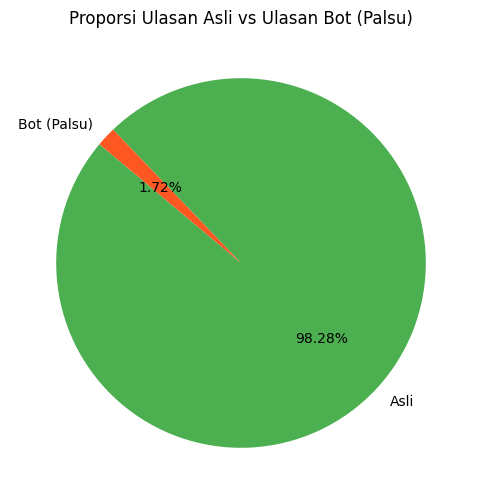

In [17]:
total = len(df)
bot_count = df['is_bot'].sum()
asli_count = total - bot_count
bot_pct = (bot_count / total) * 100

print(f"=== STATISTIK DETEKSI ===")
print(f"Total Ulasan: {total:,}")
print(f"Ulasan BOT   : {bot_count:,} ({bot_pct:.2f}%)")
print(f"Ulasan ASLI  : {asli_count:,} ({100-bot_pct:.2f}%)")

# Visualisasi Pie Chart
plt.figure(figsize=(6, 6))
plt.pie([asli_count, bot_count], labels=['Asli', 'Bot (Palsu)'], autopct='%1.2f%%', colors=['#4CAF50', '#FF5722'], startangle=140)
plt.title('Proporsi Ulasan Asli vs Ulasan Bot (Palsu)')
plt.show()

## 8. Analisis Kata-kata yang Paling Sering Muncul (Karakteristik Bot vs Asli)
Mari kita cari tahu kata-kata apa saja yang paling sering muncul di ulasan bot vs ulasan asli.

In [18]:
bot_texts = " ".join(df[df['is_bot'] == 1]['teks_bersih']).split()
asli_texts = " ".join(df[df['is_bot'] == 0]['teks_bersih']).split()

print("=== TOP 15 KATA PADA ULASAN BOT ===")
print(Counter(bot_texts).most_common(15))

print("\n=== TOP 15 KATA PADA ULASAN ASLI ===")
print(Counter(asli_texts).most_common(15))

=== TOP 15 KATA PADA ULASAN BOT ===
[('bagus', 751), ('sip', 178), ('ok', 151), ('oke', 105), ('tidak', 91), ('di', 64), ('yang', 63), ('saya', 60), ('ada', 60), ('bonus', 58), ('jos', 51), ('nya', 50), ('dan', 48), ('bisa', 48), ('promo', 37)]

=== TOP 15 KATA PADA ULASAN ASLI ===
[('barang', 34722), ('bagus', 31767), ('cepat', 20801), ('dan', 20786), ('sesuai', 19508), ('dengan', 16697), ('sudah', 16346), ('di', 14502), ('tidak', 14044), ('yang', 12160), ('pengiriman', 11551), ('sampai', 10957), ('nya', 10886), ('baik', 10163), ('terima', 9818)]


## 9. Sampel Data Hasil Deteksi
Mari kita tampilkan contoh ulasan yang ditandai sebagai BOT.

In [19]:
print("=== CONTOH ULASAN TERDETEKSI BOT/PALSU ===")
df_bot_samples = df[df['is_bot'] == 1][['reviewContent', 'dup_count']].head(10)
for idx, row in df_bot_samples.iterrows():
    print(f"- [{row['dup_count']}x Duplikat] {row['reviewContent']}")

=== CONTOH ULASAN TERDETEKSI BOT/PALSU ===
- [178x Duplikat] 7
- [178x Duplikat] 21
- [178x Duplikat] 0
- [178x Duplikat] 4
- [178x Duplikat] 1
- [89x Duplikat] oke
- [14x Duplikat] sip mantap
- [599x Duplikat] bagus
- [599x Duplikat] mantap
- [1x Duplikat] bagi yang minat orderpesan barang kamisilahkan add whatsappwa085200343400langsung dari reseller tokoterimah kasih


## 10. Menyimpan Dataset Bersih dan Akurat
Dataset yang sudah ditandai bot dan dibersihkan ini disimpan sebagai referensi/data latih baru yang berakurasi tinggi.

In [20]:
# Tambah kolom standar hasil deteksi
df['reviewContent_Cleaned'] = df['teks_bersih']
df['hasil_deteksi'] = df['is_bot'].map({0: 'Asli', 1: 'Palsu'})

save_cols = ['itemId', 'category', 'name', 'rating', 'reviewTitle',
             'reviewContent', 'reviewContent_Cleaned', 'hasil_deteksi']


# Simpan juga ke root folder (digunakan evaluasi_akurasi.ipynb)
root_file = "dataset_bersih_akurat.csv"
df[save_cols].to_csv(root_file, index=False)
print(f"Tersimpan : {root_file}  <-- digunakan oleh evaluasi_akurasi.ipynb")

print(f"\nRingkasan Dataset Bersih:")
print(f"  Total Ulasan : {len(df):,} baris")
print(f"  Kolom output : {save_cols}")
print(f"\n=== DISTRIBUSI LABEL ===")
print(df['hasil_deteksi'].value_counts())
asli  = (df['hasil_deteksi'] == 'Asli').sum()
palsu = (df['hasil_deteksi'] == 'Palsu').sum()
total = len(df)
print(f"\nAsli  : {asli:,} ({asli/total*100:.2f}%)")
print(f"Palsu : {palsu:,} ({palsu/total*100:.2f}%)")

Tersimpan : dataset_bersih_akurat.csv  <-- digunakan oleh evaluasi_akurasi.ipynb

Ringkasan Dataset Bersih:
  Total Ulasan : 89,657 baris
  Kolom output : ['itemId', 'category', 'name', 'rating', 'reviewTitle', 'reviewContent', 'reviewContent_Cleaned', 'hasil_deteksi']

=== DISTRIBUSI LABEL ===
hasil_deteksi
Asli     88112
Palsu     1545
Name: count, dtype: int64

Asli  : 88,112 (98.28%)
Palsu : 1,545 (1.72%)
